# M07A — Stochastic Methods: from Simulation to Decision

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tulip-lab/pattern-classification-lab/blob/develop/M07-Stochastic-Methods/M07A-Stochastic-Methods-from-Simulation-to-Decision.ipynb)

One synthetic smart-greenhouse case connects **Monte Carlo**, **Metropolis–Hastings**, **Gibbs sampling**, **MCMC diagnostics**, **Gaussian-process regression**, **GP temporal forecasting**, and **Bayesian optimisation**. The algorithms change; the data story and evidence ledger do not.

## Purpose, prerequisites, and expected output

**Purpose.** Learn how stochastic methods turn an uncertain greenhouse state into a reviewable next experiment.

**Prerequisites.** Random variables, Normal distributions, conditional probability, means and variances, basic Python/NumPy, and reading a line chart. Matrix notation is introduced only where the GP needs it.

**By the end you can:**

1. estimate an event probability and its Monte Carlo standard error (MCSE);
2. implement MH and Gibbs updates and explain why samples repeat or zig-zag;
3. use multiple chains, effective sample size (ESS), and $\hat R$ to challenge an MCMC result;
4. condition a GP on observations and produce a time-ordered forecast;
5. use the same GP machinery to select a next experiment with an acquisition score.

**Evidence to retain.** Keep the executed outputs, seed, MC estimate and MCSE, chain diagnostics, kernel and noise settings, withheld forecast metrics, optimisation history, and one limitation for every conclusion.

## Session plan and working agreement

| Time | Activity | Evidence added to the ledger |
|---:|---|---|
| 0–30 min | Simulate heat-stress risk | estimate, MCSE, seed |
| 30–85 min | Sample an uncertain parameter | MH/Gibbs draws and diagnostics |
| 85–135 min | Move from uncertain parameters to uncertain functions | GP posterior and kernel hypothesis |
| 135–165 min | Forecast from a historical origin | MAE, interval coverage, baseline |
| 165–180 min | Spend the next experiment | acquisition history and stop rule |

Use the repeated rhythm **predict → run → explain → challenge → record**. Before changing a parameter, write down what you expect to happen. Work from top to bottom: later sections reuse functions and evidence created earlier.

### Accessibility and responsible use

Every plot is paired with printed numeric evidence. Curves use different line styles and markers as well as colour. All data are deterministic synthetic data; no download, credential, or personal data is required. A narrow uncertainty interval is not a safety guarantee: it is conditional on the model and observed regime.

## 0 · Reproducible setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

SEED = 74207
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (8.5, 4.2), "axes.grid": True, "grid.alpha": 0.22})
print({"seed": SEED, "numpy": np.__version__})

{'seed': 74207, 'numpy': '2.5.3'}


## 1 · Monte Carlo: estimate a probability we cannot read off directly

The greenhouse acts when tomorrow's maximum temperature exceeds $32^\circ$C. Under the first illustrative model,

$$T \sim \mathcal N(28, 3^2), \qquad p=\Pr(T>32).$$

One simulated temperature is a possible future, not a probability. Repeated futures estimate the event frequency. For a binary event, the estimated Monte Carlo standard error is

$$\widehat{\mathrm{MCSE}}(\hat p)=\sqrt{\frac{\hat p(1-\hat p)}{N}}.$$

**Predict before running:** if $N$ grows by a factor of 100, by roughly what factor should MCSE change?

N=   20  risk= 0.050  MCSE=0.0487
N=  100  risk= 0.090  MCSE=0.0286
N=  500  risk= 0.102  MCSE=0.0135
N=2,000  risk= 0.090  MCSE=0.0064
N=10,000  risk= 0.087  MCSE=0.0028


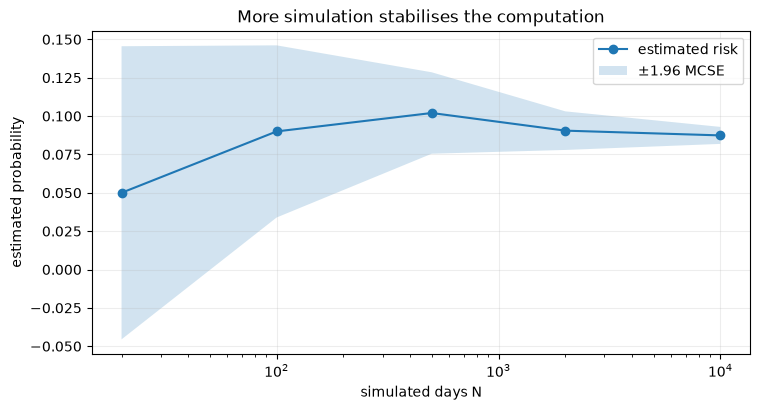

In [2]:
def estimate_heat_risk(sample_size, seed=SEED, threshold=32.0):
    local_rng = np.random.default_rng(seed)
    temperatures = local_rng.normal(loc=28.0, scale=3.0, size=sample_size)
    events = temperatures > threshold
    estimate = events.mean()
    mcse = np.sqrt(estimate * (1 - estimate) / sample_size)
    return estimate, mcse, temperatures

sizes = np.array([20, 100, 500, 2_000, 10_000])
records = [estimate_heat_risk(int(n))[:2] for n in sizes]
for n, (estimate, mcse) in zip(sizes, records):
    print(f"N={n:>5,}  risk={estimate:6.3f}  MCSE={mcse:6.4f}")

fig, ax = plt.subplots()
ax.plot(sizes, [r[0] for r in records], "o-", label="estimated risk")
ax.fill_between(sizes, [r[0]-1.96*r[1] for r in records],
                [r[0]+1.96*r[1] for r in records], alpha=.2, label="±1.96 MCSE")
ax.set(xscale="log", xlabel="simulated days N", ylabel="estimated probability",
       title="More simulation stabilises the computation")
ax.legend();

### Read the implementation line by line

- `default_rng(seed)` makes the comparison reproducible; it does not make the world deterministic.
- `temperatures > threshold` turns each simulated future into one event indicator.
- `.mean()` is the event count divided by $N$.
- MCSE describes repeat-to-repeat **computational** variation. It does not include sensor bias, a wrong Normal model, or a new climate regime.

**Change-and-predict.** Run with another seed, then with `sample_size=200_000`. The estimate can move while MCSE shrinks. Record both.

### Failure probe: zero observed events is not proof of zero risk

For a rare threshold, a small simulation can see no events. The estimate becomes zero and the plug-in MCSE also becomes zero—an obviously unsafe interpretation. Increase the simulation budget, use a rare-event method, or report a suitable binomial bound. This is a boundary case, not a successful certainty claim.

In [3]:
rare_estimate, rare_mcse, _ = estimate_heat_risk(40, seed=4, threshold=38.0)
print({"rare_event_estimate": rare_estimate, "plug_in_mcse": rare_mcse,
       "warning": "zero observed events does not establish zero probability"})

{'rare_event_estimate': np.float64(0.0), 'plug_in_mcse': np.float64(0.0), 'warning': 'zero observed events does not establish zero probability'}


## 2 · Metropolis–Hastings: sample an uncertain parameter

Now use 24 observed greenhouse maxima to infer an unknown mean temperature $\mu$. The posterior density is easy to evaluate up to a constant but we deliberately sample it to expose the mechanics used in harder models.

One random-walk MH step is:

1. propose $\mu' = \mu + \epsilon$, where $\epsilon\sim\mathcal N(0,s^2)$;
2. compare the target density at the proposal and current state;
3. accept with probability $\min(1, \exp(\log p(\mu')-\log p(\mu)))$;
4. otherwise repeat the current value—the repeat is part of the chain.

{'acceptance': 0.608, 'posterior_mean': np.float64(28.788), 'posterior_sd': np.float64(0.315), 'kept_draws': 3500}


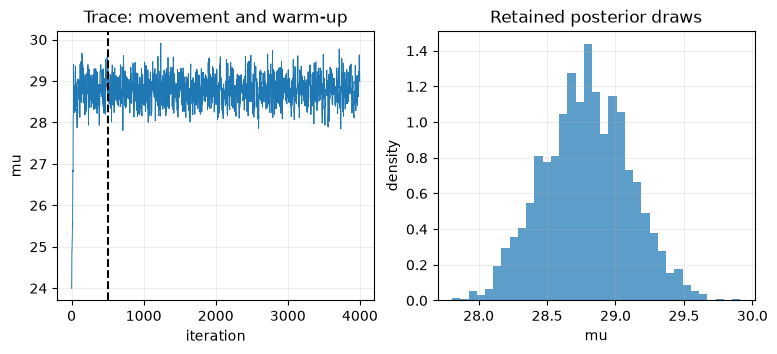

In [4]:
observed_temp = np.array([
    27.4, 28.2, 28.8, 29.1, 27.9, 30.0, 28.6, 29.4,
    28.1, 27.7, 29.8, 30.2, 28.9, 29.3, 27.8, 28.5,
    29.7, 30.1, 28.4, 29.0, 27.6, 28.7, 29.5, 28.3,
])

def log_posterior_mu(mu, data=observed_temp, obs_sd=1.6):
    log_prior = -0.5 * ((mu - 28.0) / 4.0) ** 2
    log_likelihood = -0.5 * np.sum(((data - mu) / obs_sd) ** 2)
    return log_prior + log_likelihood

def metropolis_hastings(log_target, start, draws, proposal_scale, seed):
    local_rng = np.random.default_rng(seed)
    samples = np.empty(draws)
    samples[0] = start
    accepted = 0
    for i in range(1, draws):
        proposal = samples[i - 1] + proposal_scale * local_rng.normal()
        log_alpha = log_target(proposal) - log_target(samples[i - 1])
        if np.log(local_rng.random()) < min(0.0, log_alpha):
            samples[i] = proposal
            accepted += 1
        else:
            samples[i] = samples[i - 1]  # rejection means “stay”
    return samples, accepted / (draws - 1)

mh_draws, acceptance = metropolis_hastings(log_posterior_mu, 24.0, 4_000, 0.45, SEED)
burn_in = 500
kept = mh_draws[burn_in:]
print({"acceptance": round(acceptance, 3), "posterior_mean": round(kept.mean(), 3),
       "posterior_sd": round(kept.std(ddof=1), 3), "kept_draws": len(kept)})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(mh_draws, lw=.65); axes[0].axvline(burn_in, ls="--", color="black")
axes[0].set(title="Trace: movement and warm-up", xlabel="iteration", ylabel="mu")
axes[1].hist(kept, bins=35, density=True, alpha=.72)
axes[1].set(title="Retained posterior draws", xlabel="mu", ylabel="density");

### Tune movement, not a magic acceptance number

Small proposals are accepted often but move slowly. Very large proposals are rejected often and repeat states. Neither acceptance alone nor a visually busy trace proves useful exploration.

**Experiment.** Re-run the sampler with `proposal_scale` equal to `0.03`, `0.45`, and `4.0`. Predict which chain will have the strongest lag-one dependence before looking at the diagnostics below.

## 3 · Gibbs sampling: easy conditionals can build a hard joint sample

For two correlated unknowns $(x,y)$, suppose each full conditional is Normal. Gibbs alternates

$$x^{(t+1)}\sim p(x\mid y^{(t)}), \qquad y^{(t+1)}\sim p(y\mid x^{(t+1)}).$$

The next point is produced by a horizontal move and then a vertical move. Strong correlation turns these coordinate updates into a visible zig-zag.

{'sample_correlation': np.float64(0.942), 'first_five_points': [[0.0, 0.0], [-0.02, 0.12], [0.47, -0.29], [-0.41, -0.78], [-0.39, -0.66]]}


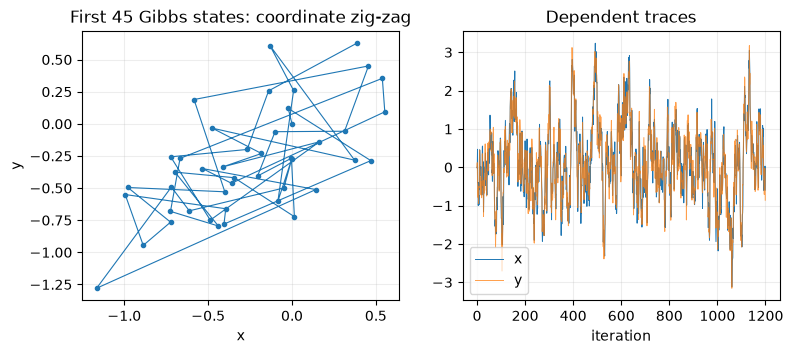

In [5]:
def gibbs_bivariate_normal(rho=0.94, draws=1_200, seed=SEED):
    local_rng = np.random.default_rng(seed)
    samples = np.zeros((draws, 2))
    conditional_sd = np.sqrt(1 - rho ** 2)
    for i in range(1, draws):
        samples[i, 0] = local_rng.normal(rho * samples[i - 1, 1], conditional_sd)
        samples[i, 1] = local_rng.normal(rho * samples[i, 0], conditional_sd)
    return samples

gibbs_draws = gibbs_bivariate_normal()
print({"sample_correlation": round(np.corrcoef(gibbs_draws.T)[0, 1], 3),
       "first_five_points": np.round(gibbs_draws[:5], 2).tolist()})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(gibbs_draws[:45, 0], gibbs_draws[:45, 1], "o-", ms=3, lw=.8)
axes[0].set(title="First 45 Gibbs states: coordinate zig-zag", xlabel="x", ylabel="y")
axes[1].plot(gibbs_draws[:, 0], lw=.7, label="x")
axes[1].plot(gibbs_draws[:, 1], lw=.7, alpha=.75, label="y")
axes[1].set(title="Dependent traces", xlabel="iteration"); axes[1].legend();

**Failure probe.** Increase `rho` to `0.995`. The marginal distributions remain valid, but coordinate movement becomes extremely slow. Reparameterisation or a sampler that moves along the posterior geometry may be more effective. “Easy conditional updates” does not imply “efficient joint exploration.”

## 4 · MCMC diagnostics: ask whether the chain supports the claim

Raw draw count is not information count. Autocorrelation reduces effective sample size (ESS); Monte Carlo error of a posterior mean is approximately $s/\sqrt{\mathrm{ESS}}$. Multiple chains started apart test whether they converge to the same region. Split-$\hat R$ near 1 is necessary, not sufficient.

{'R_hat': np.float64(1.0021), 'ESS_per_chain': [306, 268, 286, 224], 'combined_ESS': 1085, 'MCSE_of_mean': np.float64(0.0098)}


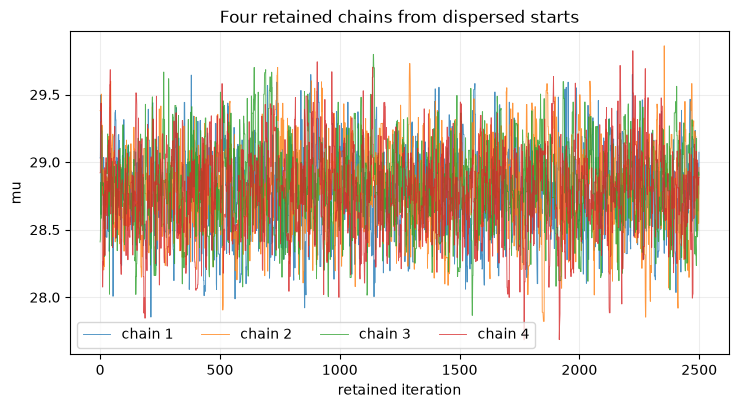

In [6]:
def autocorrelation(x, max_lag=200):
    x = np.asarray(x) - np.mean(x)
    variance = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-lag], x[lag:]) / variance
                             for lag in range(1, min(max_lag, len(x) - 1) + 1)])

def effective_sample_size(x):
    acf = autocorrelation(x)
    positive = acf[1:][acf[1:] > 0]
    return len(x) / max(1.0, 1.0 + 2.0 * positive.sum())

def rhat(chains):
    chains = np.asarray(chains)
    m, n = chains.shape
    chain_means = chains.mean(axis=1)
    between = n * chain_means.var(ddof=1)
    within = chains.var(axis=1, ddof=1).mean()
    variance_hat = ((n - 1) / n) * within + between / n
    return np.sqrt(variance_hat / within)

starts = [23.0, 26.0, 31.0, 34.0]
chains = np.vstack([
    metropolis_hastings(log_posterior_mu, start, 3_000, 0.45, SEED + i)[0][500:]
    for i, start in enumerate(starts)
])
ess_values = [effective_sample_size(chain) for chain in chains]
combined_ess = sum(ess_values)
mcse_mean = chains.std(ddof=1) / np.sqrt(combined_ess)
print({"R_hat": round(rhat(chains), 4), "ESS_per_chain": np.round(ess_values).astype(int).tolist(),
       "combined_ESS": round(combined_ess), "MCSE_of_mean": round(mcse_mean, 4)})

fig, ax = plt.subplots()
for i, chain in enumerate(chains):
    ax.plot(chain, lw=.65, alpha=.8, label=f"chain {i+1}")
ax.set(title="Four retained chains from dispersed starts", xlabel="retained iteration", ylabel="mu")
ax.legend(ncol=4);

### Diagnostic decision, not diagnostic decoration

Before interpreting the posterior, record:

- whether dispersed traces overlap and revisit the same region;
- $\hat R$ and ESS for every decision-relevant quantity, not only one convenient parameter;
- MCSE small enough for the reported precision;
- divergences, stuck chains, or missing modes that invalidate the summary.

**Failure probe.** A flat trace can be a chain stuck in one mode. Agreement among chains that all started in that mode can also mislead. Diagnostics challenge a sampling claim; they cannot certify an unknown model as true.

## Bridge · The random object changes, but the question persists

MCMC represented uncertainty over a finite set of **parameters**. The greenhouse now needs the response at many unseen control settings and future times. A Gaussian process represents uncertainty over an entire **function**.

The common question is unchanged: *which possibilities remain plausible after seeing the evidence, and how should that uncertainty affect the next claim?*

## 5 · Gaussian-process regression: condition a distribution over functions

A GP is specified by a mean function and a kernel. The RBF kernel

$$k(x,x')=\sigma_f^2\exp\left[-\frac{(x-x')^2}{2\ell^2}\right]$$

states that nearby inputs should have similar latent responses. The length-scale $\ell$ controls how quickly the function may change. We compute the exact posterior with a Cholesky factorisation; no external GP package is needed.

{'observations': 5, 'mean_posterior_sd': np.float64(0.268), 'widest_sd': np.float64(0.624)}


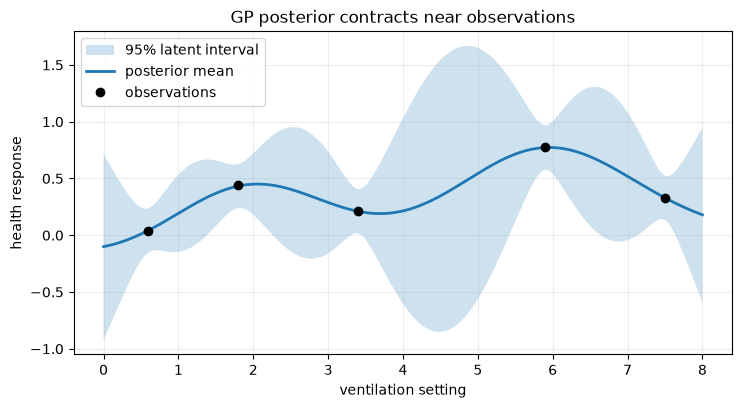

In [7]:
def rbf_kernel(x1, x2, length_scale=1.2, amplitude=1.0):
    x1 = np.atleast_1d(x1)[:, None]
    x2 = np.atleast_1d(x2)[None, :]
    return amplitude ** 2 * np.exp(-0.5 * ((x1 - x2) / length_scale) ** 2)

def gp_posterior(train_x, train_y, test_x, length_scale=1.2, amplitude=1.0, noise=0.12):
    K = rbf_kernel(train_x, train_x, length_scale, amplitude) + (noise ** 2 + 1e-8) * np.eye(len(train_x))
    Ks = rbf_kernel(train_x, test_x, length_scale, amplitude)
    Kss = rbf_kernel(test_x, test_x, length_scale, amplitude)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, train_y))
    mean = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    covariance = Kss - v.T @ v
    sd = np.sqrt(np.clip(np.diag(covariance), 0, None))
    return mean, sd

control_x = np.array([0.6, 1.8, 3.4, 5.9, 7.5])
health_y = np.array([0.04, 0.44, 0.21, 0.78, 0.33])
grid_x = np.linspace(0, 8, 241)
gp_mean, gp_sd = gp_posterior(control_x, health_y, grid_x, length_scale=1.15, noise=0.10)
print({"observations": len(control_x), "mean_posterior_sd": round(gp_sd.mean(), 3),
       "widest_sd": round(gp_sd.max(), 3)})

fig, ax = plt.subplots()
ax.fill_between(grid_x, gp_mean - 1.96 * gp_sd, gp_mean + 1.96 * gp_sd,
                alpha=.22, label="95% latent interval")
ax.plot(grid_x, gp_mean, lw=2, label="posterior mean")
ax.plot(control_x, health_y, "ko", label="observations")
ax.set(title="GP posterior contracts near observations", xlabel="ventilation setting", ylabel="health response")
ax.legend();

### Read and challenge the GP implementation

- `K` expresses similarity among observed inputs; noise is added only on its diagonal.
- `Ks` connects observed and prediction inputs.
- Cholesky solves replace an explicit matrix inverse.
- The posterior mean is a weighted combination of observed responses.
- Posterior uncertainty contracts where the kernel connects predictions strongly to data.

**Change-and-predict.** Try `length_scale=0.25` and `3.0`; then increase `noise`. Before running, sketch which posterior should be more wiggly and which should trust observations less.

**Failure probe.** Duplicate inputs with nearly zero noise can make `K` numerically singular. The small jitter in the code helps computation but does not solve conflicting measurements or a bad kernel story.

## 6 · GP temporal forecasting: preserve the historical viewpoint

For forecasting, the input is time $t$. Training uses only observations at or before the forecast origin. The withheld future is shown only after predictions are fixed. We compare against a last-value baseline and report both accuracy and interval coverage.

{'forecast_origin': 22, 'horizon': 7, 'GP_MAE': np.float64(0.345), 'last_value_MAE': np.float64(1.016), '95pct_coverage': np.float64(1.0)}


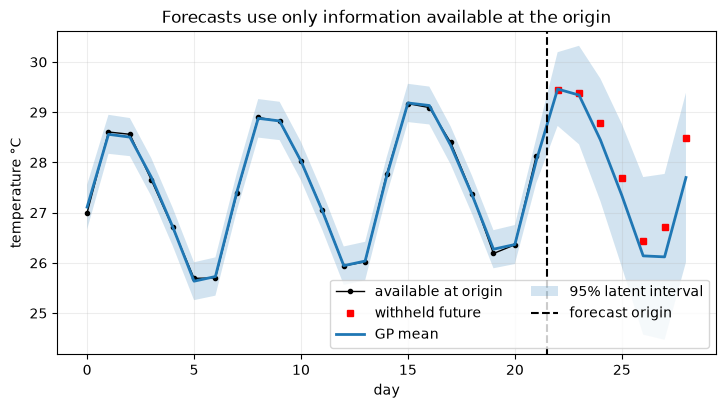

In [8]:
days = np.arange(32)
temperature = 27 + 1.65*np.sin(2*np.pi*days/7) + 0.045*days + 0.28*np.sin(1.83*days)
origin = 22
horizon = 7
train_t, train_y = days[:origin], temperature[:origin]
test_t, test_y = days[origin:origin+horizon], temperature[origin:origin+horizon]

def periodic_kernel(x1, x2, period=7.0, length_scale=1.2, amplitude=1.8):
    x1 = np.atleast_1d(x1)[:, None]
    x2 = np.atleast_1d(x2)[None, :]
    distance = np.abs(x1 - x2)
    return amplitude**2 * np.exp(-2*np.sin(np.pi*distance/period)**2 / length_scale**2)

def temporal_kernel(x1, x2):
    seasonal = periodic_kernel(x1, x2)
    slow_change = rbf_kernel(x1, x2, length_scale=4.0, amplitude=0.8)
    return seasonal + slow_change

def gp_posterior_with_kernel(train_x, train_y, test_x, kernel, noise=0.28):
    K = kernel(train_x, train_x) + (noise**2 + 1e-8)*np.eye(len(train_x))
    Ks = kernel(train_x, test_x)
    Kss = kernel(test_x, test_x)
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, train_y))
    mean = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    sd = np.sqrt(np.clip(np.diag(Kss - v.T @ v), 0, None))
    return mean, sd

forecast_grid = np.arange(origin + horizon)
center = train_y.mean()
forecast_mean_centered, forecast_sd = gp_posterior_with_kernel(
    train_t, train_y - center, forecast_grid, temporal_kernel
)
forecast_mean = forecast_mean_centered + center
pred_mean = forecast_mean[origin:origin+horizon]
pred_sd = forecast_sd[origin:origin+horizon]
mae = np.mean(np.abs(pred_mean - test_y))
baseline_mae = np.mean(np.abs(train_y[-1] - test_y))
coverage = np.mean(np.abs(test_y - pred_mean) <= 1.96 * pred_sd)
print({"forecast_origin": int(origin), "horizon": horizon, "GP_MAE": round(mae, 3),
       "last_value_MAE": round(baseline_mae, 3), "95pct_coverage": round(coverage, 3)})

fig, ax = plt.subplots()
ax.plot(train_t, train_y, "ko-", ms=3, lw=1, label="available at origin")
ax.plot(test_t, test_y, "rs", ms=5, label="withheld future")
ax.plot(forecast_grid, forecast_mean, lw=2, label="GP mean")
ax.fill_between(forecast_grid, forecast_mean-1.96*forecast_sd, forecast_mean+1.96*forecast_sd,
                alpha=.2, label="95% latent interval")
ax.axvline(origin-.5, ls="--", color="black", label="forecast origin")
ax.set(title="Forecasts use only information available at the origin", xlabel="day", ylabel="temperature °C")
ax.legend(ncol=2);

### Backtest the process, not one fortunate split

Repeat several historical origins and aggregate MAE, interval coverage, and interval width. A useful forecast should beat a relevant baseline and have calibrated uncertainty. Coverage of one seven-day window is coarse evidence, not a guarantee.

**Failure probe: regime change.** Add `temperature[24:] += 3`. A stationary kernel trained before the change can become confidently wrong. The correct response may be a change-point model, a shorter training window, an external covariate, or a human safety escalation—not merely a smaller optimisation tolerance.

## Bridge · The GP stays; the task and input change

Temporal forecasting used a GP with input **time** and asked: *what happens next?* Bayesian optimisation uses the same posterior machinery with input **control setting** and asks: *where should we evaluate next?*

Prediction becomes decision when an acquisition function scores not only the predicted outcome but also decision-relevant uncertainty.

## 7 · Bayesian optimisation: spend one expensive experiment

We use an upper confidence bound (UCB),

$$a(x)=\mu(x)+\kappa\sigma(x),$$

as a transparent acquisition score. $\kappa=0$ exploits the current mean; larger $\kappa$ gives uncertainty more value. The hidden objective is available here only to simulate the outcome after selection.

step  selected_x  observed_y  uncertainty_at_selection
   1        6.40       0.735                     0.515
   2        6.90       0.815                     0.112
   3        6.85       0.808                     0.064
   4        6.80       0.799                     0.049
   5        6.95       0.821                     0.045
{'best_observed': np.float64(0.821), 'evaluations': 8}


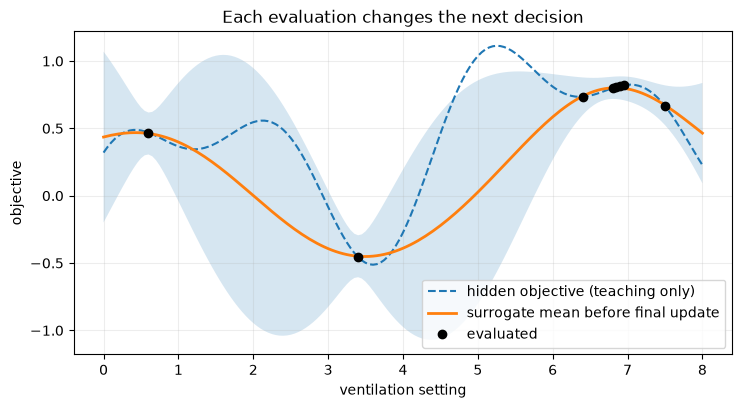

In [9]:
def hidden_objective(x):
    return 0.55*np.sin(1.35*x) + 0.32*np.cos(2.55*x) + 0.095*x

def run_bayesian_optimisation(kappa=1.2, budget=5):
    candidates = np.linspace(0, 8, 161)
    evaluated = [0.6, 3.4, 7.5]
    history = []
    for step in range(budget):
        values = np.array([hidden_objective(x) for x in evaluated])
        mean, sd = gp_posterior(np.array(evaluated), values, candidates,
                                length_scale=1.25, amplitude=.7, noise=.08)
        acquisition = mean + kappa*sd
        acquisition[np.isin(np.round(candidates, 8), np.round(evaluated, 8))] = -np.inf
        next_x = float(candidates[np.argmax(acquisition)])
        history.append((step+1, next_x, hidden_objective(next_x), float(sd[np.argmax(acquisition)])))
        evaluated.append(next_x)
    return np.array(evaluated), history, candidates, mean, sd

evaluated, bo_history, candidates, bo_mean, bo_sd = run_bayesian_optimisation()
print("step  selected_x  observed_y  uncertainty_at_selection")
for row in bo_history:
    print(f"{row[0]:>4}  {row[1]:>10.2f}  {row[2]:>10.3f}  {row[3]:>24.3f}")
print({"best_observed": round(max(hidden_objective(evaluated)), 3), "evaluations": len(evaluated)})

fig, ax = plt.subplots()
ax.plot(candidates, hidden_objective(candidates), "--", lw=1.5, label="hidden objective (teaching only)")
ax.plot(candidates, bo_mean, lw=2, label="surrogate mean before final update")
ax.fill_between(candidates, bo_mean-1.96*bo_sd, bo_mean+1.96*bo_sd, alpha=.18)
ax.plot(evaluated, hidden_objective(evaluated), "ko", label="evaluated")
ax.set(title="Each evaluation changes the next decision", xlabel="ventilation setting", ylabel="objective")
ax.legend();

### Challenge and stop

Compare `kappa=0` with `kappa=2.5`. A larger exploration weight should spend more budget in uncertain regions, but it is not automatically safer or better. Compare against random search under the same budget and repeated seeds.

Stop when the budget is exhausted, expected improvement is negligible, the recommendation is stable across reasonable model variants, or safety/model checks fail. The objective, constraints, acquisition, experiment history, and stopping rule are all part of the result.

## Final evidence ledger and exit ticket

Complete this record in your own words:

| Claim | Evidence retained | Limitation that remains |
|---|---|---|
| Heat-stress probability | estimate, MCSE, sample size, seed | simulation model may be wrong |
| Plausible mean temperature | chains, burn-in, ESS, MCSE, $\hat R$ | posterior model may omit structure |
| Unknown response function | kernel, noise, posterior plot | kernel restricts plausible shapes |
| Seven-day forecast | origin, horizon, MAE, coverage, baseline | regime change may break calibration |
| Next experiment | acquisition, history, budget, stop rule | surrogate and constraints may be incomplete |

**Exit ticket.** In three sentences: (1) name the random object in Monte Carlo/MCMC/GP, (2) name one diagnostic that changes whether you trust each output, and (3) explain why a GP forecast and Bayesian optimisation can share code but answer different questions.

### Optional challenges

1. Implement a block bootstrap that respects short-range time dependence.
2. Compare MH proposal scales using ESS per second rather than acceptance alone.
3. Add a weekly periodic kernel to the temporal GP and use rolling-origin backtests.
4. Add a safety constraint to Bayesian optimisation and refuse unsafe candidates.

## References and provenance

- Newly authored synthetic reconstruction for M07; no legacy cells, outputs, or data are copied.
- Robert & Casella, *Monte Carlo Statistical Methods*.
- Gelman et al., *Bayesian Data Analysis* and modern rank-normalised MCMC diagnostics.
- Rasmussen & Williams, *Gaussian Processes for Machine Learning*.
- Shahriari et al., “Taking the Human Out of the Loop: A Review of Bayesian Optimization.”
- NumPy and Matplotlib documentation for the software interface used here.

Code cells: MPL-2.0. Original narrative: CC BY-NC-SA 4.0. See the repository licensing files for details.